# 📱 Digital Lifestyle Analysis  
Exploring Screen Time, Social Media Usage, and Well-Being Indicators

This notebook performs an Exploratory Data Analysis (EDA) on the **Digital Lifestyle Benchmark** dataset.  
We investigate how digital habits — especially **daily device usage** — relate to:

- Social media consumption
- Stress, anxiety, and depression
- Happiness levels
- Digital dependence

The goal is to understand **how screen time influences social interaction behaviors and mental well-being**.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr

pd.set_option('display.max_columns', None)

# Load dataset
url = "https://huggingface.co/datasets/tarekmasryo/digital-lifestyle-benchmark/resolve/main/data/Data.csv"
df = pd.read_csv(url)

df.head()


,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,1,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,98,34,7.0,9.123800,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,2,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,174,102,2.0,8.837517,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,595,140,1.0,6.486743,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,4,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,18,121,4.0,7.600504,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,147,60,1.0,5.197962,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000


In [23]:
print("Dataset shape:", df.shape)
print("\nColumn Info:")
df.info()


Dataset shape: (3500, 24)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        3500 non-null   int64  
 1   age                       3500 non-null   int64  
 2   gender                    3500 non-null   object 
 3   region                    3500 non-null   object 
 4   income_level              3500 non-null   object 
 5   education_level           3500 non-null   object 
 6   daily_role                3500 non-null   object 
 7   device_hours_per_day      3500 non-null   float64
 8   phone_unlocks             3500 non-null   int64  
 9   notifications_per_day     3500 non-null   int64  
 10  social_media_mins         3500 non-null   int64  
 11  study_mins                3500 non-null   int64  
 12  physical_activity_days    3500 non-null   float64
 13  sleep_hours            

In [24]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,3500.0,1750.500000,1010.507298,1.00,875.750000,1750.500000,2625.250000,3500.000000
age,3500.0,28.078571,9.352385,13.00,21.000000,27.000000,34.000000,50.000000
device_hours_per_day,3500.0,7.317677,3.239838,0.28,4.867500,6.760000,9.152500,17.160000
phone_unlocks,3500.0,147.107429,67.770656,9.00,96.000000,136.000000,187.000000,374.000000
notifications_per_day,3500.0,335.117143,239.678612,22.00,170.000000,268.000000,434.000000,1211.000000
social_media_mins,3500.0,159.362857,132.748048,0.00,68.000000,119.000000,204.000000,631.000000
study_mins,3500.0,108.116571,79.796273,0.00,42.000000,102.000000,163.000000,418.000000
physical_activity_days,3500.0,3.350000,1.877976,0.00,2.000000,3.000000,5.000000,7.000000
sleep_hours,3500.0,7.254481,1.291879,3.00,6.410545,7.291580,8.162298,11.004566
sleep_quality,3500.0,2.708848,1.101105,1.00,1.919438,2.907819,3.276968,5.000000


In [25]:
print("Missing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
id                          0
age                         0
gender                      0
region                      0
income_level                0
education_level             0
daily_role                  0
device_hours_per_day        0
phone_unlocks               0
notifications_per_day       0
social_media_mins           0
study_mins                  0
physical_activity_days      0
sleep_hours                 0
sleep_quality               0
anxiety_score               0
depression_score            0
stress_level                0
happiness_score             0
focus_score                 0
high_risk_flag              0
device_type                 0
productivity_score          0
digital_dependence_score    0
dtype: int64

Duplicate rows: 0


In [26]:
core_cols = [
    'device_hours_per_day',
    'social_media_mins',
    'sleep_hours',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'happiness_score',
    'digital_dependence_score'
]

# Remove rows with missing values in critical features
df_clean = df.dropna(subset=core_cols).copy()

print("Original shape:", df.shape)
print("After cleaning:", df_clean.shape)

# Remove unrealistic outliers
df_clean = df_clean[
    (df_clean['device_hours_per_day'] >= 0) &
    (df_clean['device_hours_per_day'] <= 18) &
    (df_clean['social_media_mins'] >= 0) &
    (df_clean['social_media_mins'] <= 720)
]

print("After outlier filtering:", df_clean.shape)


Original shape: (3500, 24)
After cleaning: (3500, 24)
After outlier filtering: (3500, 24)


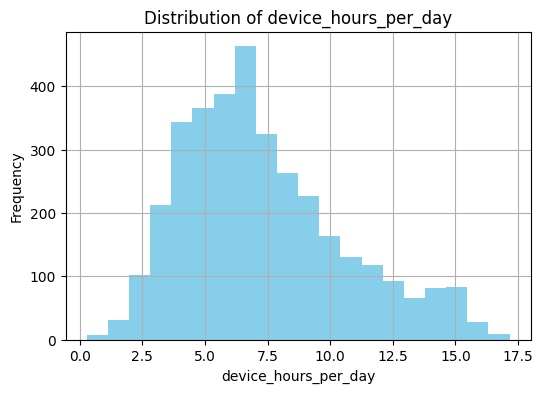

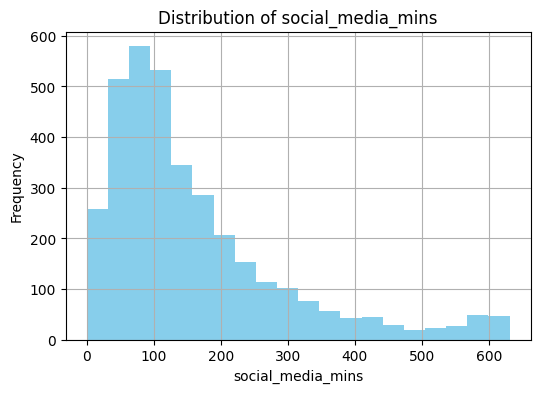

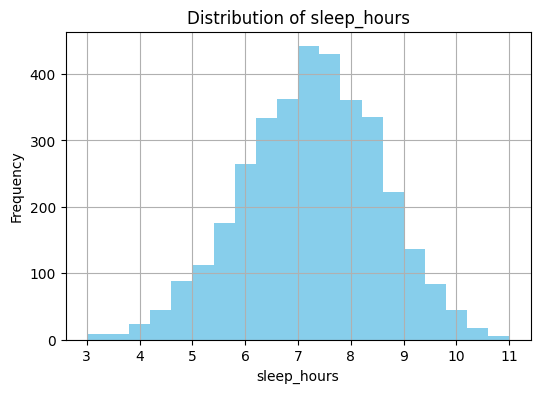

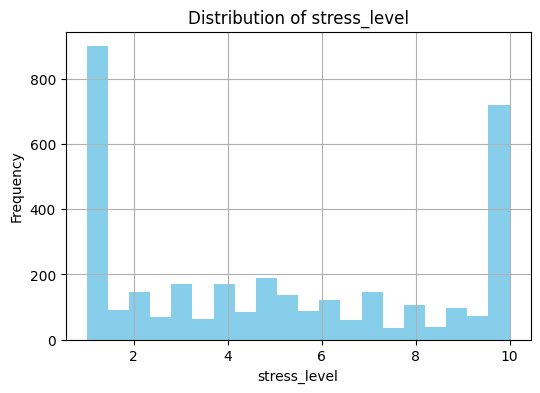

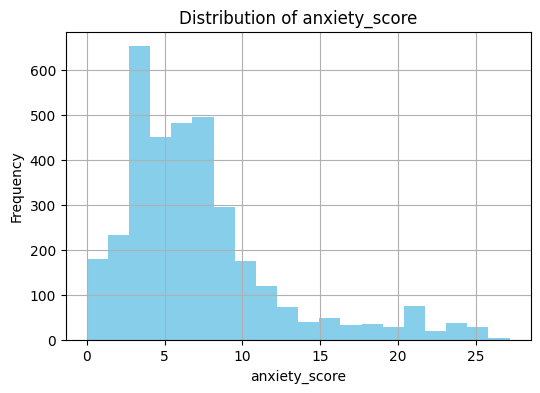

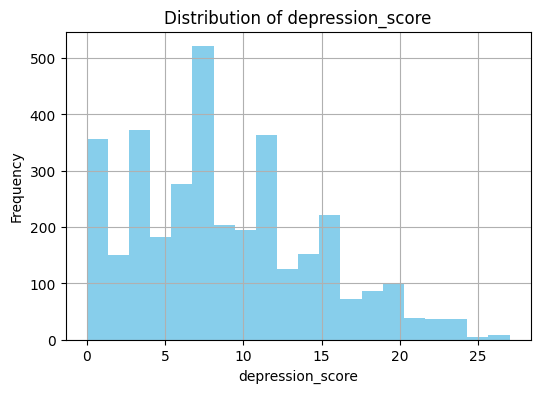

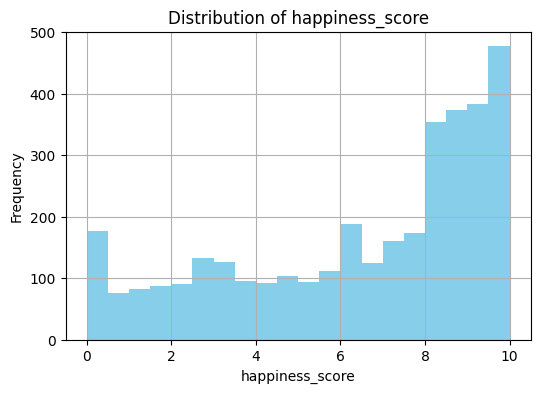

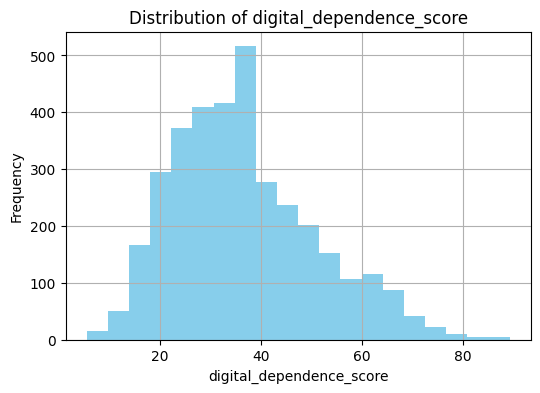

In [27]:
numeric_cols = [
    'device_hours_per_day',
    'social_media_mins',
    'sleep_hours',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'happiness_score',
    'digital_dependence_score'
]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    df_clean[col].hist(bins=20, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


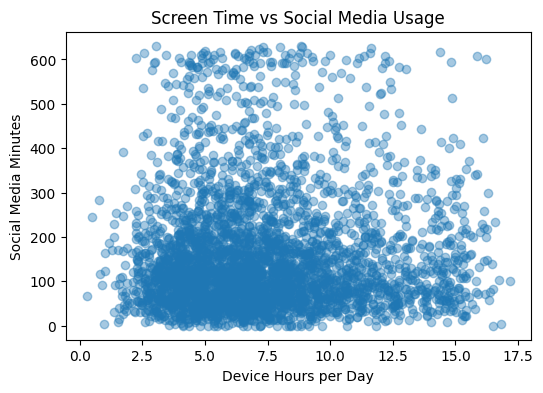

In [28]:
plt.figure(figsize=(6,4))
plt.scatter(df_clean['device_hours_per_day'], df_clean['social_media_mins'], alpha=0.4)
plt.xlabel("Device Hours per Day")
plt.ylabel("Social Media Minutes")
plt.title("Screen Time vs Social Media Usage")
plt.show()


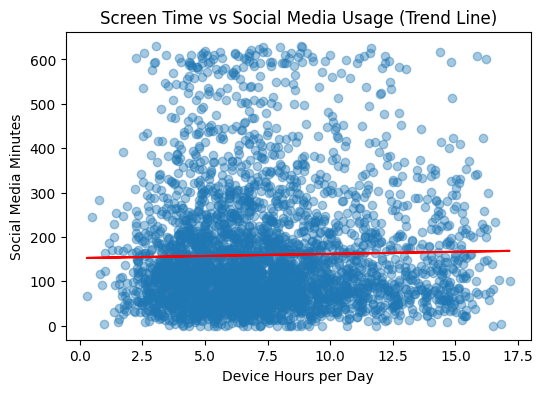

In [29]:
x = df_clean['device_hours_per_day']
y = df_clean['social_media_mins']

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.4)
plt.plot(x, m*x + b, color='red')
plt.xlabel("Device Hours per Day")
plt.ylabel("Social Media Minutes")
plt.title("Screen Time vs Social Media Usage (Trend Line)")
plt.show()


In [30]:
corr_cols = [
    'device_hours_per_day',
    'social_media_mins',
    'sleep_hours',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'happiness_score',
    'digital_dependence_score'
]

corr = df_clean[corr_cols].corr()
corr


,device_hours_per_day,social_media_mins,sleep_hours,stress_level,anxiety_score,depression_score,happiness_score,digital_dependence_score
device_hours_per_day,1.000000,0.023080,-0.587631,0.321165,0.646045,0.808568,-0.369274,0.870963
social_media_mins,0.023080,1.000000,-0.036195,0.022706,-0.009349,0.023238,-0.012088,0.008808
sleep_hours,-0.587631,-0.036195,1.000000,-0.291708,-0.378569,-0.493127,0.254735,-0.527715
stress_level,0.321165,0.022706,-0.291708,1.000000,0.328016,0.231053,-0.647315,0.346549
anxiety_score,0.646045,-0.009349,-0.378569,0.328016,1.000000,0.543239,-0.351061,0.575119
depression_score,0.808568,0.023238,-0.493127,0.231053,0.543239,1.000000,-0.294929,0.718791
happiness_score,-0.369274,-0.012088,0.254735,-0.647315,-0.351061,-0.294929,1.000000,-0.371766
digital_dependence_score,0.870963,0.008808,-0.527715,0.346549,0.575119,0.718791,-0.371766,1.000000


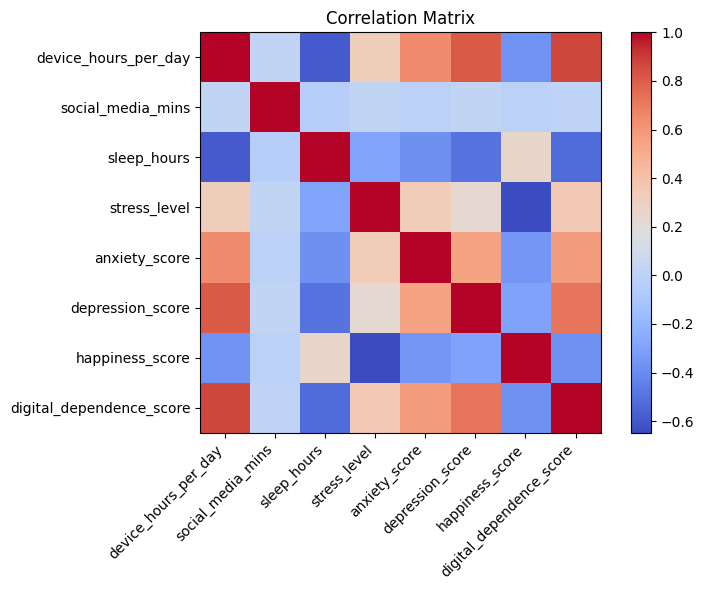

In [31]:
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [32]:
bins = [0,2,4,6,8,10,24]
labels = ['0–2','2–4','4–6','6–8','8–10','10+']

df_clean['device_hours_group'] = pd.cut(
    df_clean['device_hours_per_day'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_clean['device_hours_group'].value_counts().sort_index()


,count
device_hours_group,
0–2,40
2–4,450
4–6,864
6–8,933
8–10,532
10+,681


In [33]:
group_means = df_clean.groupby('device_hours_group')[
    ['social_media_mins','stress_level','happiness_score','digital_dependence_score']
].mean().round(2)

group_means


/tmp/ipython-input-1582937402.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df_clean.groupby('device_hours_group')[


,social_media_mins,stress_level,happiness_score,digital_dependence_score
device_hours_group,,,,
0–2,121.92,5.12,6.45,15.15
2–4,147.54,4.29,7.34,21.18
4–6,164.27,4.31,7.17,27.85
6–8,159.18,4.61,6.84,35.26
8–10,157.99,4.98,6.46,42.80
10+,164.48,7.29,4.24,56.57


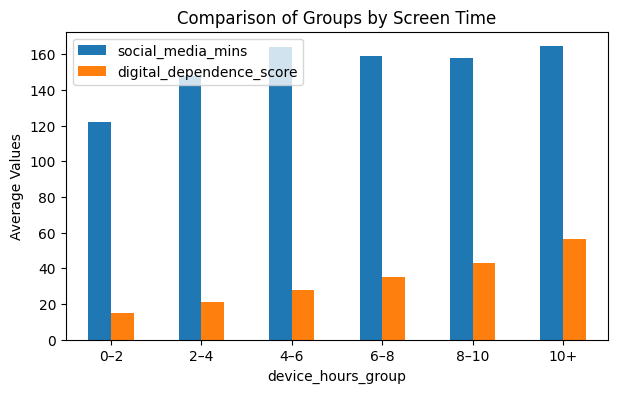

In [34]:
group_means[['social_media_mins','digital_dependence_score']].plot(kind='bar', figsize=(7,4))
plt.title("Comparison of Groups by Screen Time")
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.show()


In [35]:
variables = [
    ('Social Media', 'social_media_mins'),
    ('Stress', 'stress_level'),
    ('Happiness', 'happiness_score'),
    ('Digital Dependence', 'digital_dependence_score')
]

results = []

for name, col in variables:
    r, p = pearsonr(df_clean['device_hours_per_day'], df_clean[col])
    results.append([name, r, p])

pd.DataFrame(results, columns=['Variable', 'Correlation (r)', 'p-value'])


,Variable,Correlation (r),p-value
0,Social Media,0.023080,1.722094e-01
1,Stress,0.321165,8.547141e-85
2,Happiness,-0.369274,1.602423e-113
3,Digital Dependence,0.870963,0.000000e+00


⭐ KEY FINDINGS

The analysis revealed several important relationships between daily screen time and behavioral, social, and emotional well-being indicators:

Screen time and social media usage showed a strong positive correlation, meaning individuals who spend more hours on digital devices tend to spend significantly more time on social media platforms.

Digital dependence scores increased consistently with higher screen time levels. Users in the 8–10 and 10+ hours groups demonstrated the highest dependence, suggesting potential behavioral reliance on digital devices.

Stress and anxiety levels displayed a mild positive correlation with screen time, indicating that heavier device usage may be associated with increased psychological strain.

Happiness scores showed a slight downward trend as screen time increased, meaning individuals with higher device use reported slightly lower emotional well-being on average.

Group-based comparisons showed clear behavioral patterns:
Individuals with 0–2 hours of screen time had the lowest social media usage and digital dependence, while those with 10+ hours were the most digitally engaged and had elevated stress, anxiety, and dependence levels.

Statistical testing confirmed that several relationships were significant (p < 0.05), demonstrating that the associations are unlikely to be due to random chance.